In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
img1 = cv2.imread("raw-captures/lit.jpg")
img2 = cv2.imread("raw-captures/dim.jpg")
print(img1.shape)
print(img2.shape)

(2592, 4608, 3)
(2592, 4608, 3)


In [6]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [7]:
orb = cv2.ORB_create()

In [8]:
kp1, des1 = orb.detectAndCompute(gray1, None)

kp2, des2 = orb.detectAndCompute(gray2, None)

In [9]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

In [10]:
matches = bf.knnMatch(des1, des2, k=2)

In [11]:
print(des1 is None)
print(des2 is None)

print(des1.shape)
print(des2.shape)

False
False
(500, 32)
(500, 32)


In [12]:
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good Matches:", len(good_matches))

Good Matches: 101


In [13]:
src_pts = np.float32(
    [kp1[m.queryIdx].pt for m in good_matches]
).reshape(-1, 1, 2)

dst_pts = np.float32(
    [kp2[m.trainIdx].pt for m in good_matches]
).reshape(-1, 1, 2)

In [14]:
H, mask = cv2.findHomography(
    dst_pts,
    src_pts,
    cv2.RANSAC,
    5.0
)

In [15]:
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

print(H)
print(mask.sum())

[[ 1.87195396e+00 -9.11109516e-02 -4.70399417e+02]
 [ 3.62548751e-01  1.31877772e+00 -2.80520691e+02]
 [ 3.59908099e-04 -6.00182339e-05  1.00000000e+00]]
79


In [16]:
height, width = img1.shape[:2]

aligned = cv2.warpPerspective(
    img2,
    H,
    (width, height)
)

In [19]:
blend1 = cv2.addWeighted(img1, 0.5, aligned, 0.5, 0)

blend2 = cv2.addWeighted(img1, 0.7, aligned, 0.3, 0)

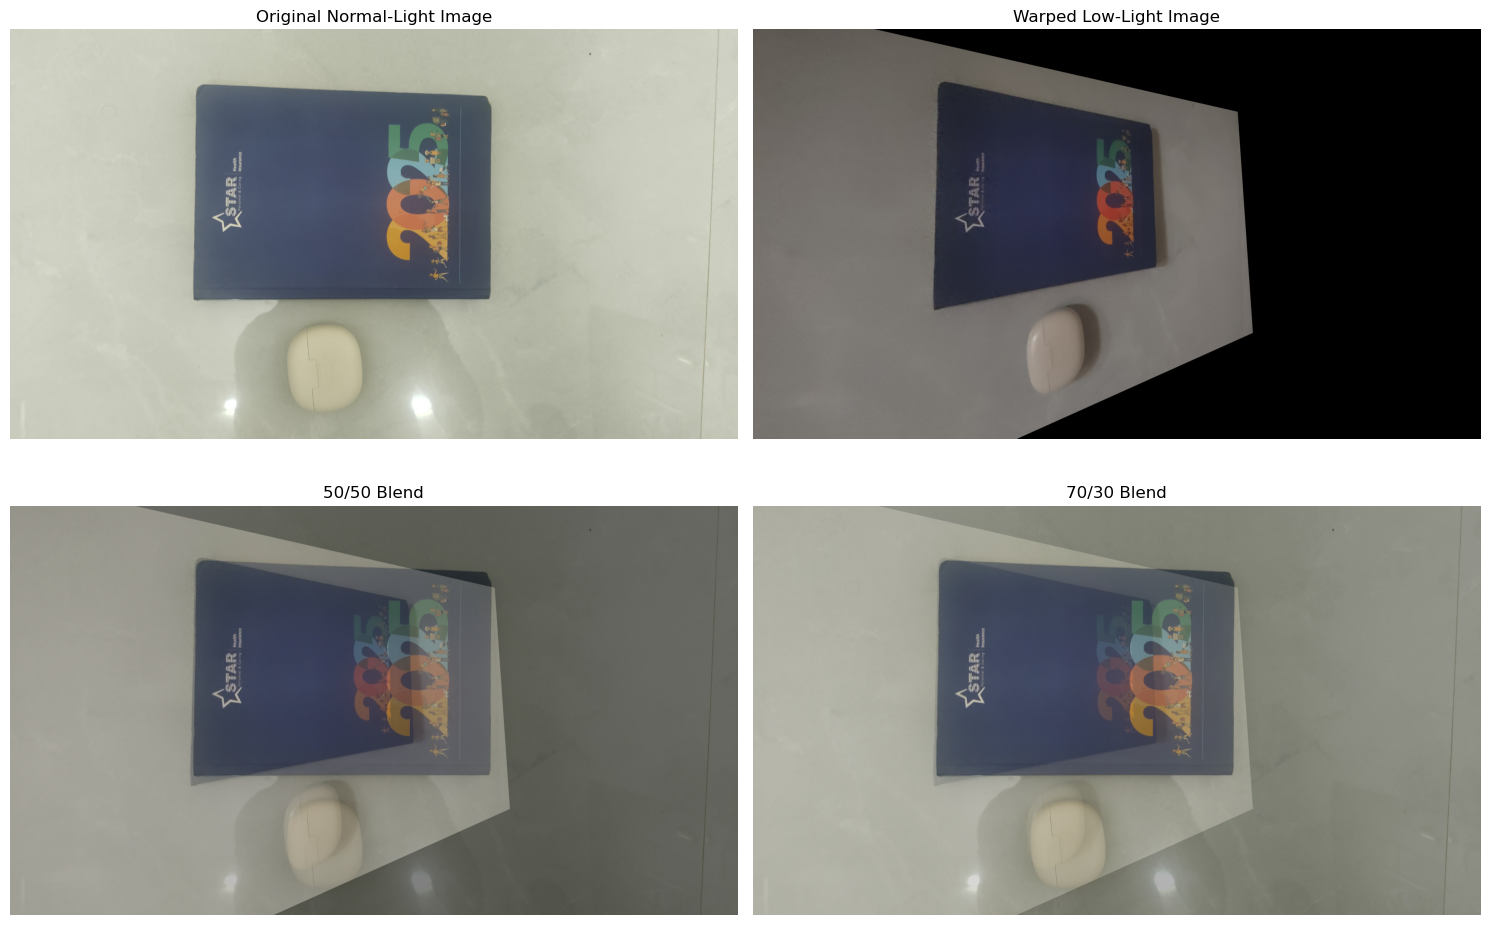

In [22]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Original Normal-Light Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.title("Warped Low-Light Image")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(blend1, cv2.COLOR_BGR2RGB))
plt.title("50/50 Blend")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(blend2, cv2.COLOR_BGR2RGB))
plt.title("70/30 Blend")
plt.axis("off")

plt.tight_layout()
plt.show()

ORB successfully detected and matched features between the normal-light and low-light images. Using these matches, a homography was estimated with RANSAC, and the low-light image was warped onto the normal-light image. The warped image aligned well with the reference image, although minor ghosting remained due to slight changes in camera position and viewpoint. The black regions around the warped image are expected because perspective warping leaves pixels outside the transformed image undefined.